<a href="https://colab.research.google.com/github/jyotinayak321/IBM-training_-learning-/blob/main/standarlization.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [116]:
import numpy as np # linear algebra
import pandas as pd #data processing
import matplotlib.pyplot as plt
import seaborn as sns

In [117]:
df = pd.read_csv('IPL Matches 2008-2020.csv')

In [118]:
df=df.iloc[:,2:]

In [119]:
df.sample(5)

,date,player_of_match,venue,neutral_venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,eliminator,method,umpire1,umpire2
559,2016-05-13,MP Stoinis,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,0,Mumbai Indians,Kings XI Punjab,Mumbai Indians,bat,Kings XI Punjab,wickets,7.0,N,NaN,HDPK Dharmasena,CK Nandan
547,2016-05-03,RR Pant,Saurashtra Cricket Association Stadium,0,Gujarat Lions,Delhi Daredevils,Delhi Daredevils,field,Delhi Daredevils,wickets,8.0,N,NaN,CB Gaffaney,BNJ Oxenford
571,2016-05-22,YK Pathan,Eden Gardens,0,Kolkata Knight Riders,Sunrisers Hyderabad,Sunrisers Hyderabad,field,Kolkata Knight Riders,runs,22.0,N,NaN,KN Ananthapadmanabhan,M Erasmus
808,2020-10-25,RD Gaikwad,Dubai International Cricket Stadium,0,Royal Challengers Bangalore,Chennai Super Kings,Royal Challengers Bangalore,bat,Chennai Super Kings,wickets,8.0,N,NaN,C Shamshuddin,RK Illingworth
176,2011-04-09,SK Trivedi,"Rajiv Gandhi International Stadium, Uppal",0,Deccan Chargers,Rajasthan Royals,Rajasthan Royals,field,Rajasthan Royals,wickets,8.0,N,NaN,RE Koertzen,SK Tarapore


# **TRAIN test split**


In [120]:
from sklearn.model_selection import train_test_split  # used for to train and test the data set

#X_train:Training input data,
#X_test:Testing input data,
#Y_train:Training output (labels).
#Y_test:Testing output (labels).
X_train,X_test,Y_train,Y_test = train_test_split(df.drop('winner',axis=1),
                                                 df['winner'],
                                                 test_size=0.2,
                                                 random_state=42
                                                 )

X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((652, 14), (164, 14), (652,), (164,))

# **Text ko numbers mein convert karo**

pd.get_dummies() text (categorical) data ko numbers mein convert karta hai.
Machine Learning model text ko nahi samajhta.

imp note:
axis=1 matlab columns par operation.

axis=0 → rows
axis=1 → columns
fill_value=0 --->Jo column missing hoga usme 0 bhar do.
join='left' → Train dataset ko reference maanta hai.

In [121]:
## 2. One-Hot Encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

# Dono datasets ke columns same karo
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

# **StandardScaler**


Use it with:

Logistic Regression
K-Nearest Neighbors (KNN)
Support Vector Machine (SVM)
Neural Networks
PCA

***StandardScaler is used to make all numerical features have a similar scale.***
# What does it do?

It changes the data so that:

Mean (average) = 0
Standard deviation = 1

In [122]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
#fit the scaler to the train set,it will learn the parameters
scaler.fit(X_train)

X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

**scaler.mean_ ka matlab hai training data ke har feature (column) ka mean (average) jo StandardScaler ne fit() ke time calculate kiya tha**

fit() ke baad kya hota hai?

Jab tum likhte ho:

scaler.fit(X_train)

To StandardScaler har numerical column ke liye:

Mean (average) nikalta hai.
Standard deviation nikalta hai.
In values ko apne andar store kar leta hai.


          z=x−μ​/σ

In [123]:
scaler.mean_

array([8.74233129e-02, 1.71170047e+01, 1.53374233e-03, 1.53374233e-03,
       3.06748466e-03, 1.53374233e-03, 1.53374233e-03, 1.53374233e-03,
       1.53374233e-03, 1.53374233e-03, 3.06748466e-03, 1.53374233e-03,
       1.53374233e-03, 1.53374233e-03, 3.06748466e-03, 1.53374233e-03,
       3.06748466e-03, 1.53374233e-03, 1.53374233e-03, 1.53374233e-03,
       1.53374233e-03, 3.06748466e-03, 1.53374233e-03, 1.53374233e-03,
       1.53374233e-03, 1.53374233e-03, 1.53374233e-03, 3.06748466e-03,
       3.06748466e-03, 1.53374233e-03, 1.53374233e-03, 3.06748466e-03,
       1.53374233e-03, 1.53374233e-03, 3.06748466e-03, 1.53374233e-03,
       1.53374233e-03, 1.53374233e-03, 1.53374233e-03, 1.53374233e-03,
       3.06748466e-03, 3.06748466e-03, 1.53374233e-03, 1.53374233e-03,
       1.53374233e-03, 3.06748466e-03, 1.53374233e-03, 1.53374233e-03,
       3.06748466e-03, 1.53374233e-03, 1.53374233e-03, 3.06748466e-03,
       1.53374233e-03, 1.53374233e-03, 3.06748466e-03, 1.53374233e-03,
      

In [124]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [125]:
np.round(X_train.describe(), 1) #Ye numerical columns ki statistics deta hai aur 1 yaha Dataset ki summary ko 1 decimal place tak round karke dikhati hai

,neutral_venue,result_margin
count,652.0,641.0
mean,0.1,17.1
std,0.3,21.8
min,0.0,1.0
25%,0.0,6.0
50%,0.0,8.0
75%,0.0,19.0
max,1.0,146.0


In [126]:
np.round(X_train_scaled.describe(), 1)

,neutral_venue,result_margin,date_2008-04-18,date_2008-04-19,date_2008-04-20,date_2008-04-21,date_2008-04-22,date_2008-04-24,date_2008-04-25,date_2008-04-26,...,umpire2_SJ Davis,umpire2_SJA Taufel,umpire2_SK Tarapore,umpire2_SL Shastri,umpire2_SS Hazare,umpire2_Subroto Das,umpire2_TH Wijewardene,umpire2_VA Kulkarni,umpire2_VK Sharma,umpire2_YC Barde
count,652.0,641.0,652.0,652.0,652.0,652.0,652.0,652.0,652.0,652.0,...,652.0,652.0,652.0,652.0,652.0,652.0,652.0,652.0,652.0,652.0
mean,-0.0,-0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,...,0.0,0.0,0.0,-0.0,0.0,0.0,-0.0,-0.0,-0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
min,-0.3,-0.7,-0.0,-0.0,-0.1,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.3,-0.2,-0.1,-0.1,-0.0,-0.1,-0.2,-0.2,-0.1
25%,-0.3,-0.5,-0.0,-0.0,-0.1,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.3,-0.2,-0.1,-0.1,-0.0,-0.1,-0.2,-0.2,-0.1
50%,-0.3,-0.4,-0.0,-0.0,-0.1,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.3,-0.2,-0.1,-0.1,-0.0,-0.1,-0.2,-0.2,-0.1
75%,-0.3,0.1,-0.0,-0.0,-0.1,-0.0,-0.0,-0.0,-0.0,-0.0,...,-0.0,-0.3,-0.2,-0.1,-0.1,-0.0,-0.1,-0.2,-0.2,-0.1
max,3.2,5.9,25.5,25.5,18.0,25.5,25.5,25.5,25.5,25.5,...,25.5,3.5,5.2,7.6,12.7,25.5,12.7,5.1,5.9,11.4


# Effect of **Scaling**

* Interview mein yaad rakhna
* plt.subplots() → Ek figure mein multiple graphs banata hai.
* ax1.scatter() → Original data ka scatter plot.
* ax2.scatter() → Scaled data ka scatter plot.
* set_title() → Graph ka title set karta hai.
* plt.show() → Graph ko display karta hai.



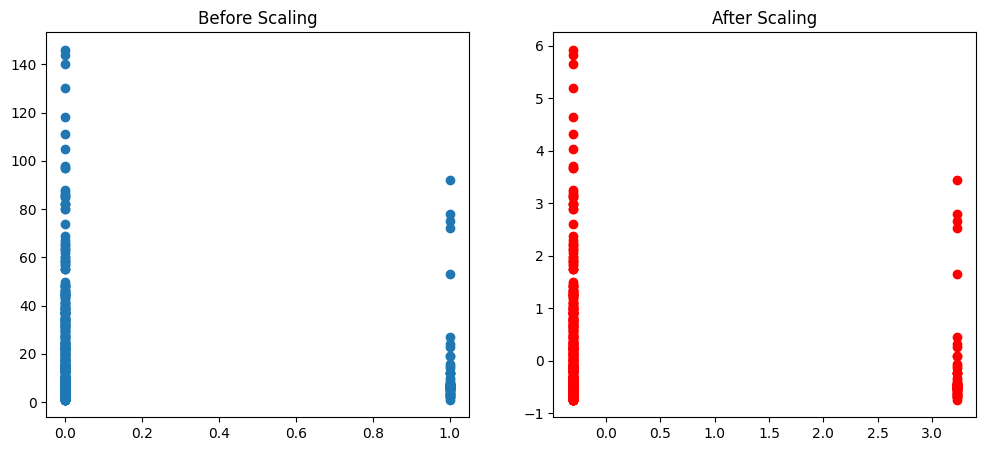

In [127]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['neutral_venue'], X_train['result_margin'])
ax1.set_title("Before Scaling")
ax2.scatter(X_train_scaled['neutral_venue'], X_train_scaled['result_margin'],color='red')
ax2.set_title("After Scaling")
plt.show()

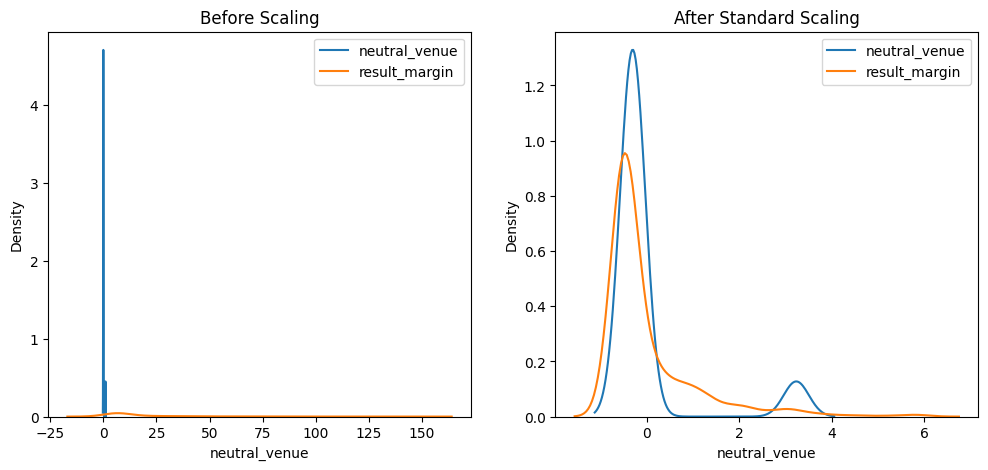

In [128]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create two plots side by side
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# ---------------- BEFORE SCALING ----------------
ax1.set_title("Before Scaling")

# Distribution of neutral_venue
sns.kdeplot(X_train['neutral_venue'], ax=ax1, label='neutral_venue')

# Distribution of result_margin
sns.kdeplot(X_train['result_margin'], ax=ax1, label='result_margin')

ax1.legend()

# ---------------- AFTER SCALING ----------------
ax2.set_title("After Standard Scaling")

# Distribution after scaling
sns.kdeplot(X_train_scaled['neutral_venue'], ax=ax2, label='neutral_venue')

sns.kdeplot(X_train_scaled['result_margin'], ax=ax2, label='result_margin')

ax2.legend()

# Display the plots
plt.show()

# ***Comparison of Distributions***

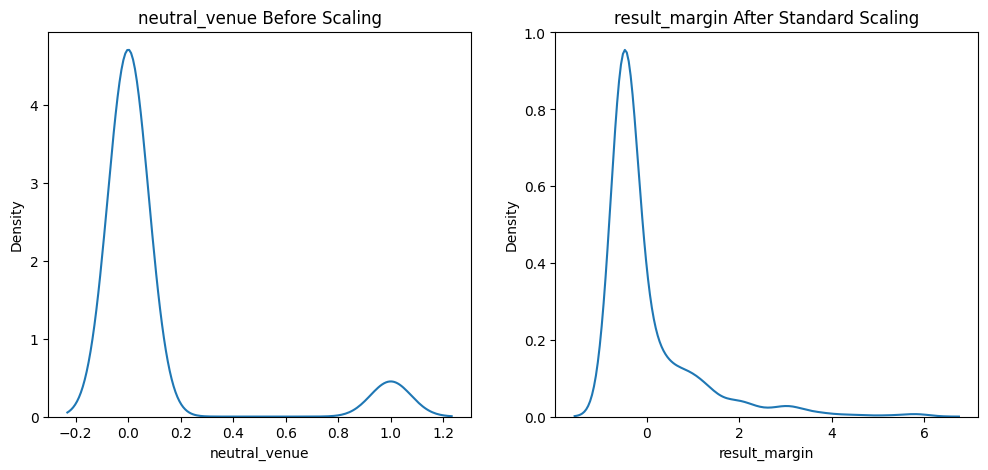

In [129]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# before scaling
ax1.set_title('neutral_venue Before Scaling')
sns.kdeplot(X_train['neutral_venue'], ax=ax1)

# after scaling
ax2.set_title('result_margin After Standard Scaling')
sns.kdeplot(X_train_scaled['result_margin'], ax=ax2)
plt.show()

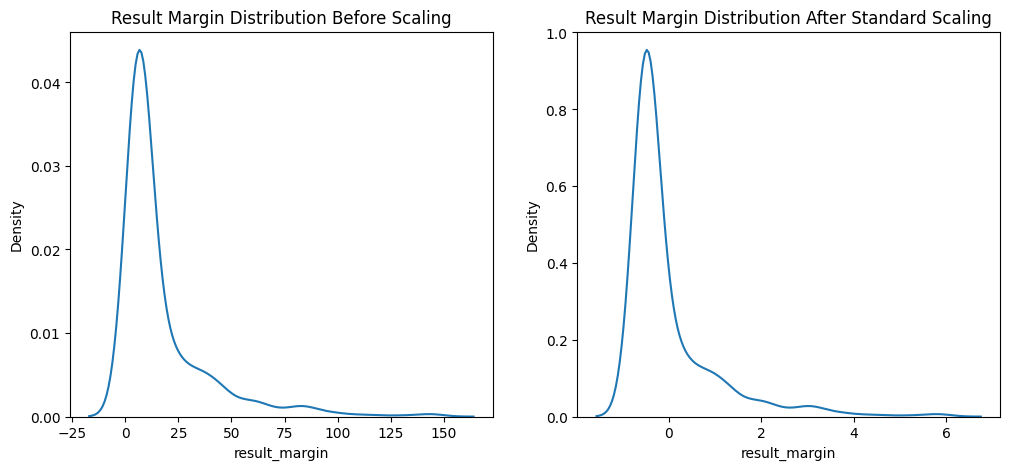

In [130]:
# Create two plots side by side
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# ---------------- BEFORE SCALING ----------------
ax1.set_title('Result Margin Distribution Before Scaling')
sns.kdeplot(X_train['result_margin'], ax=ax1)

# ---------------- AFTER SCALING ----------------
ax2.set_title('Result Margin Distribution After Standard Scaling')
sns.kdeplot(X_train_scaled['result_margin'], ax=ax2)

# Display the plots
plt.show()

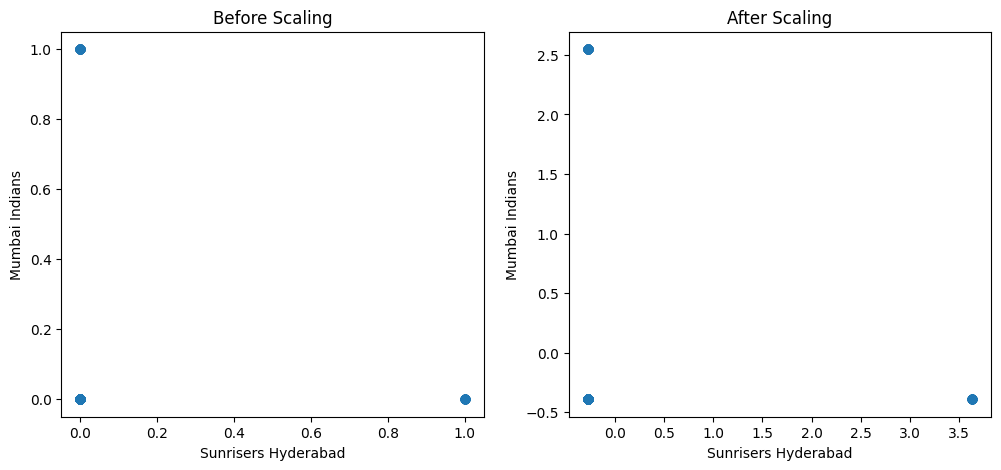

In [131]:
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

ax1.scatter(X_train['team1_Sunrisers Hyderabad'], X_train['team1_Mumbai Indians'])
ax1.set_title('Before Scaling')

ax2.scatter(X_train_scaled['team1_Sunrisers Hyderabad'], X_train_scaled['team1_Mumbai Indians'])
ax2.set_title('After Scaling')
ax1.set_xlabel('Sunrisers Hyderabad')
ax1.set_ylabel('Mumbai Indians')
ax2.set_xlabel('Sunrisers Hyderabad')
ax2.set_ylabel('Mumbai Indians')
plt.show()

***Why scaling is important?***

In [132]:
from sklearn.linear_model import LogisticRegression

In [133]:
lr = LogisticRegression()         #Model banao
lr_scaled = LogisticRegression()   #Model train karo

In [135]:
print(X_train.isnull().sum())

neutral_venue              0
result_margin             11
date_2008-04-18            0
date_2008-04-19            0
date_2008-04-20            0
                          ..
umpire2_Subroto Das        0
umpire2_TH Wijewardene     0
umpire2_VA Kulkarni        0
umpire2_VK Sharma          0
umpire2_YC Barde           0
Length: 913, dtype: int64


NaN ko fill ya remove karo
Option 1 (Recommended): Mean se fill karo
Option 2: Rows delete karo
X_train = X_train.dropna()

In [136]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='mean')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [137]:
lr.fit(X_train, Y_train)
y_pred = lr.predict(X_test)

ValueError: Input contains NaN

In [138]:
print(X_train.shape)
print(Y_train.shape)
print(Y_train.head())

(652, 913)
(652,)
448                 Mumbai Indians
335                 Mumbai Indians
294               Rajasthan Royals
684          Kolkata Knight Riders
79     Royal Challengers Bangalore
Name: winner, dtype: object


In [140]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

NotFittedError: This LogisticRegression instance is not fitted yet. Call 'fit' with appropriate arguments before using this estimator.

In [100]:
lr.fit(X_train, Y_train)

ValueError: could not convert string to float: 'Wankhede Stadium'

In [101]:
print(X_train.dtypes)

venue             object
neutral_venue      int64
team1             object
team2             object
toss_winner       object
toss_decision     object
result            object
result_margin    float64
eliminator        object
method            object
umpire1           object
umpire2           object
dtype: object


In [103]:
#One-Hot Encoding
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

In [104]:
#Train aur Test ke columns same karo
X_train, X_test = X_train.align(
    X_test,
    join='left',
    axis=1,
    fill_value=0
)

In [105]:
print(X_train.dtypes)

neutral_venue                int64
result_margin              float64
venue_Barabati Stadium        bool
venue_Brabourne Stadium       bool
venue_Buffalo Park            bool
                            ...   
umpire2_Subroto Das           bool
umpire2_TH Wijewardene        bool
umpire2_VA Kulkarni           bool
umpire2_VK Sharma             bool
umpire2_YC Barde              bool
Length: 186, dtype: object


In [107]:
#missinng value handle
from sklearn.impute import SimpleImputer


imputer = SimpleImputer(strategy='most_frequent')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [108]:
#Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [110]:
# model tarain
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, Y_train)

ValueError: Input contains NaN

In [111]:
print(X_train.isnull().sum()[X_train.isnull().sum() > 0])

AttributeError: 'numpy.ndarray' object has no attribute 'isnull'

In [112]:
import numpy as np

print(np.isnan(X_train).sum())

0


In [113]:
X_train = pd.DataFrame(X_train)

print(X_train.isnull().sum())

0      0
1      0
2      0
3      0
4      0
      ..
181    0
182    0
183    0
184    0
185    0
Length: 186, dtype: int64


ValueError: Input contains NaN

lr.fit(X_train,y_train)
lr_scaled.fit(X_train_scaled,y_train)

In [144]:
print(np.isnan(X_train).sum())

0


In [145]:
print(type(X_train))
print(type(Y_train))

print(X_train.shape)
print(Y_train.shape)

<class 'numpy.ndarray'>
<class 'pandas.core.series.Series'>
(652, 913)
(652,)


In [146]:
import numpy as np

print("NaN:", np.isnan(X_train).sum())
print("Infinity:", np.isinf(X_train).sum())
print("Max:", np.nanmax(X_train))
print("Min:", np.nanmin(X_train))
print("Dtype:", X_train.dtype)

NaN: 0
Infinity: 0
Max: 146.0
Min: 0.0
Dtype: float64


In [147]:
print(Y_train.isnull().sum())
print(Y_train.dtype)
print(Y_train.unique()[:10])

2
object
['Mumbai Indians' 'Rajasthan Royals' 'Kolkata Knight Riders'
 'Royal Challengers Bangalore' 'Kings XI Punjab' 'Chennai Super Kings'
 'Kochi Tuskers Kerala' 'Rising Pune Supergiant' 'Sunrisers Hyderabad'
 'Delhi Capitals']


In [148]:
print(Y_train[Y_train.isnull()])

511    NaN
241    NaN
Name: winner, dtype: object


In [149]:
df = df.dropna(subset=['winner'])

In [150]:
print(df['winner'].isnull().sum())

0


In [154]:
from sklearn.linear_model import LogisticRegression

In [155]:
lr = LogisticRegression()
lr_scaled = LogisticRegression()

In [160]:
lr.fit(X_train, Y_train)
lr_scaled.fit(X_train_scaled, Y_train)

ValueError: Input contains NaN

In [161]:
print(Y_train.isnull().sum())

2


In [162]:
df = df.dropna(subset=['winner'])

In [163]:
X = df.drop('winner', axis=1)
y = df['winner']

In [164]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [165]:
X_train = pd.get_dummies(X_train)
X_test = pd.get_dummies(X_test)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [166]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='most_frequent')

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

In [167]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [169]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)
lr_scaled = LogisticRegression(max_iter=1000)

lr.fit(X_train, Y_train)
lr_scaled.fit(X_train_scaled, Y_train)

LogisticRegression(max_iter=1000)

In [171]:
y_pred = lr.predict(X_test)
y_pred_scaled = lr_scaled.predict(X_test_scaled)

In [172]:
from sklearn.metrics import accuracy_score


print("Actual :", accuracy_score(Y_test, y_pred))
print("Scaled :", accuracy_score(Y_test, y_pred_scaled))

In [174]:
from sklearn.tree import DecisionTreeClassifier

In [175]:
dt = DecisionTreeClassifier()
dt_scaled = DecisionTreeClassifier()

In [177]:
dt.fit(X_train, Y_train)
dt_scaled.fit(X_train_scaled, Y_train)

DecisionTreeClassifier()

In [178]:
y_pred = dt.predict(X_test)
y_pred_scaled = dt_scaled.predict(X_test_scaled)

In [181]:
print("Actual",accuracy_score(Y_test,y_pred))
print("Scaled",accuracy_score(Y_test,y_pred_scaled))

Actual 0.5766871165644172
Scaled 0.588957055214724


In [182]:
df.describe()

,neutral_venue,result_margin
count,812.000000,799.000000
mean,0.094828,17.321652
std,0.293157,22.068427
min,0.000000,1.000000
25%,0.000000,6.000000
50%,0.000000,8.000000
75%,0.000000,19.500000
max,1.000000,146.000000


***Effect of Outlier***

AttributeError: 'DataFrame' object has no attribute 'append'